# Ejercicios extra 
Para practicar lo que vimos en clase. Hay **6 ejercicios**: 3 de redes neuronales con Keras y 3 de YOLO. No son difíciles; con repasar el notebook de clase os salen.

**Instrucciones**
- Resuelve cada ejercicio en la celda que pone `# TODO`.
- No tienen que salir perfectos: lo importante es practicar el flujo.
- Cada ejercicio trae **pistas** y te dice a qué bloque de clase se parece.

## Preparación (ejecuta esto antes de empezar)

In [1]:
# Instala lo necesario (solo la primera vez; si ya lo tienes, no pasa nada).
%pip install tensorflow matplotlib numpy scikit-learn ultralytics

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras

# (Windows) por si imprimes algun emoji en un print, evita errores de codificacion:
import sys
try:
    sys.stdout.reconfigure(encoding='utf-8')
except Exception:
    pass

print('Listo para empezar. A practicar!')

Listo para empezar. A practicar!


# Parte A — Redes Neuronales (Keras)

## Ejercicio 1 — El flujo completo con MNIST

Repite tú solo, de principio a fin, lo que hicimos en clase con los dígitos. Pasos:

1. Carga **MNIST** y **normaliza** (divide las imágenes entre 255).
2. Construye una red `Sequential`: `Input(28,28)` → `Flatten` → `Dense(128, 'relu')` → `Dense(10, 'softmax')`.
3. Compila con `optimizer='adam'`, `loss='sparse_categorical_crossentropy'`, `metrics=['accuracy']`.
4. Entrena **5 epochs**.
5. Evalúa en el conjunto de **test** e imprime el accuracy.
6. Predice **5 imágenes** del test y muéstralas con el dígito que dice la red.

 **Objetivo:** superar el **95%** en test.


In [15]:
# Ejercicio 1 - El flujo completo con MNIST
# Pasos: cargar -> normalizar -> construir -> compilar -> entrenar -> evaluar -> predecir

import sys
try:
    sys.stdout.reconfigure(encoding='utf-8')
except Exception:
    pass

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

print('TensorFlow :', tf.__version__)
print('Keras      :', keras.__version__)
print('NumPy      :', np.__version__)
print('Todo OK. (La CPU es suficiente para la clase de hoy.)')

TensorFlow : 2.21.0
Keras      : 3.14.1
NumPy      : 2.2.6
Todo OK. (La CPU es suficiente para la clase de hoy.)


Imagenes de entrenamiento: (60000, 28, 28)
Etiquetas de entrenamiento: (60000,)
Imagenes de test: (10000, 28, 28)
Primeras 10 etiquetas: [5 0 4 1 9 2 1 3 1 4]


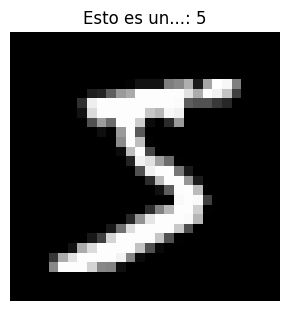

In [16]:
# Cargamos el dataset de MNIST
keras.datasets.mnist.load_data() # devuelve dos tuplas: la primera contiene los datos de entrenamiento (X_train, y_train)
# y la segunda contiene los datos de prueba (X_test, y_test).

(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

print('Imagenes de entrenamiento:', X_train.shape)
print('Etiquetas de entrenamiento:', y_train.shape)
print('Imagenes de test:', X_test.shape)
print('Primeras 10 etiquetas:', y_train[:10])

plt.figure(figsize=(3.5, 3.5))
plt.imshow(X_train[0], cmap='gray')
plt.title(f'Esto es un...: {str(y_train[0])}')
plt.axis('off')
plt.show()

In [17]:
print(X_train[0][4:16, 6:20]) # muestra una parte de la imagen del primer dígito (un 5) para que veamos los valores numéricos de los píxeles.
print()
print("Cada pixel tiene un valor entre 0 y 255, donde 0 representa el color negro y 255 representa el color blanco. Los valores intermedios representan diferentes tonos de gris.")

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   3  18  18  18 126 136 175  26]
 [  0   0  30  36  94 154 170 253 253 253 253 253 225 172]
 [  0  49 238 253 253 253 253 253 253 253 253 251  93  82]
 [  0  18 219 253 253 253 253 253 198 182 247 241   0   0]
 [  0   0  80 156 107 253 253 205  11   0  43 154   0   0]
 [  0   0   0  14   1 154 253  90   0   0   0   0   0   0]
 [  0   0   0   0   0 139 253 190   2   0   0   0   0   0]
 [  0   0   0   0   0  11 190 253  70   0   0   0   0   0]
 [  0   0   0   0   0   0  35 241 225 160 108   1   0   0]
 [  0   0   0   0   0   0   0  81 240 253 253 119  25   0]
 [  0   0   0   0   0   0   0   0  45 186 253 253 150  27]]

Cada pixel tiene un valor entre 0 y 255, donde 0 representa el color negro y 255 representa el color blanco. Los valores intermedios representan diferentes tonos de gris.


In [18]:
# Normalizamos los datos
X_train = X_train /255.0 # Normalizamos los valores de los píxeles a un rango de 0 a 1
X_test = X_test /255.0
print('Listo. Ahora los datos están normalizados.', X_train.min(), 'a', X_train.max())

Listo. Ahora los datos están normalizados. 0.0 a 1.0


## Ejercicio 1 — El flujo completo con MNIST

Repite tú solo, de principio a fin, lo que hicimos en clase con los dígitos. Pasos:

1. Carga **MNIST** y **normaliza** (divide las imágenes entre 255).
2. Construye una red `Sequential`: `Input(28,28)` → `Flatten` → `Dense(128, 'relu')` → `Dense(10, 'softmax')`.
3. Compila con `optimizer='adam'`, `loss='sparse_categorical_crossentropy'`, `metrics=['accuracy']`.
4. Entrena **5 epochs**.
5. Evalúa en el conjunto de **test** e imprime el accuracy.
6. Predice **5 imágenes** del test y muéstralas con el dígito que dice la red.

 **Objetivo:** superar el **95%** en test.


In [19]:
modelo = keras.Sequential([

    keras.layers.Input(shape=(28, 28)), # ENTRADA: Imagenes de 28x28 pixeles
    keras.layers.Flatten(), # APLANAR, convierte la matriz de 28x28 en una fila de 784 elementos numeros
                            # (las capas DENSE necesitan trabajar con vectores)

    keras.layers.Dense(128, activation='relu'),  # CAPA OCULTA "densa": 128 neuronas conectadas al 784 del vector.
                                                 # DENSE = Cada neurona se conecta a TODAS las entradas.
                                                 # activacion relu es la "chispa" no lineal que permite aprender formas complejas
                                                 # sin ella la red solo sabría hacer rectas.
           
    keras.layers.Dense(10, activation='softmax') # CAPA DE SALIDA: 10 neuronas (una por digito  0-9).
                                                 # softmax convierte las 10 salidas en probabilidades que suman 1.
])


modelo.compile(
    optimizer='adam', # Adam # es un algoritmo de optimización que ajusta los pesos de la red para minimizar la función de pérdida.
    loss='sparse_categorical_crossentropy', # Función de pérdida para clasificación multi-clase
    metrics=['accuracy'] # Métrica para evaluar el rendimiento
)
modelo.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
# fit es el método que se encarga de entrenar el modelo. Toma los datos de entrenamiento (X_train, y_train) y los utiliza para ajustar los pesos de la red neuronal.
# Entrenamos el modelo con los datos de entrenamiento, durante 5 épocas, y reservamos el 10% de los datos para validación.
historia = modelo.fit(X_train, y_train, epochs=5, validation_split=0.1)  

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9215 - loss: 0.2784 - val_accuracy: 0.9693 - val_loss: 0.1191
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9647 - loss: 0.1196 - val_accuracy: 0.9692 - val_loss: 0.0987
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9749 - loss: 0.0825 - val_accuracy: 0.9787 - val_loss: 0.0797
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9813 - loss: 0.0625 - val_accuracy: 0.9770 - val_loss: 0.0771
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9847 - loss: 0.0481 - val_accuracy: 0.9773 - val_loss: 0.0779


In [21]:
# evaluate es el método que se encarga de evaluar el rendimiento del modelo en un conjunto de datos de prueba (X_test, y_test).
# Devuelve la pérdida y la precisión.
# verbose=0 es para que no imprima el progreso de la evaluación.

test_acc = modelo.evaluate(X_test, y_test, verbose=0)[1]
print('Accuracy en test:', test_acc * 100, '%')
print('Es decir: acierta', round(test_acc*100), 'de cada 100 digitos que nunca habia visto')

Accuracy en test: 97.47999906539917 %
Es decir: acierta 97 de cada 100 digitos que nunca habia visto


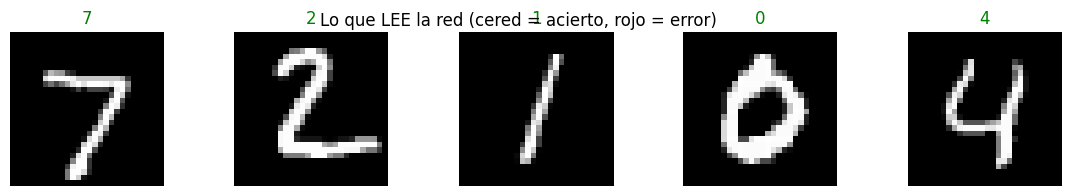

In [22]:
# predict es el método que se encarga de hacer predicciones con el modelo entrenado. Toma un conjunto de datos (X_test) y devuelve las probabilidades de cada clase para cada muestra.
preds = modelo.predict(X_test[:5], verbose=0)#las 5 primeras imagenes del test, para ver que lee la red

fig, ax = plt.subplots(1, 5, figsize=(14, 2))  #crea 5 minigraficos para mostrar las 5 primeras imagenes del test, y lo que lee la red
for k in range(5): #recorre las 5 primeras imagenes del test
    p = int(np.argmax(preds[k])) #argmax devuelve el indice de la clase con mayor probabilidad, es decir, lo que la red "cree" que es cada imagen
    ax[k].imshow(X_test[k], cmap='gray') #muestra la imagen del test
    color = 'green' if p == y_test[k] else 'red' #si la prediccion es correcta (p == y_test[k]) el titulo se muestra en verde, sino en rojo
    ax[k].set_title(str(p), color=color) #titulo del grafico es la prediccion de la red, con el color correspondiente
    ax[k].axis('off')

plt.suptitle('Lo que LEE la red (cered = acierto, rojo = error)')
plt.show()

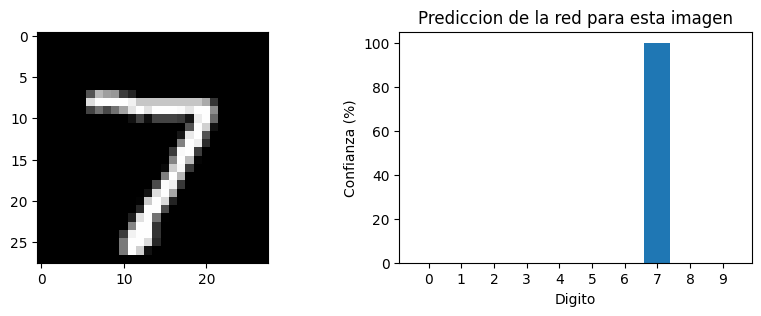

In [23]:
i=0

probs = modelo.predict(X_test[i:i+1], verbose=0)[0] #predice la probabilidad de cada clase para la imagen i del test

fig, ax = plt.subplots(1, 2, figsize=(10, 3)) #crea dos minigraficos para mostrar la imagen del test y las probabilidades de cada clase
ax[0].imshow(X_test[i], cmap='gray') #muestra la imagen del test
ax[1].bar(range(10), probs*100) #muestra un grafico de barras con las probabilidades de cada clase
ax[1].set_xticks(range(10)) #pone los numeros del 0 al 9 en el eje x del grafico de barras
ax[1].set_xlabel('Digito'); ax[1].set_ylabel('Confianza (%)')
ax[1].set_title('Prediccion de la red para esta imagen')
plt.show()

Elige una imagen cualquiera del test (cambia el índice `i`), **predícela** y responde en el chat:
1. ¿Qué dígito dice la red?
2. ¿Con qué % de confianza?
3. ¿Acierta?

Imagen del test numero 350 la red dice 1 con una confianza del 99.4 % y la etiqueta real es 1


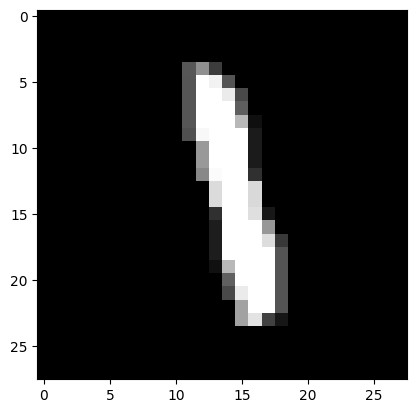

In [24]:
i = 350

probs = modelo.predict(X_test[i:i+1], verbose=0)[0] #predice la probabilidad de cada clase para la imagen i del test
pred = int(probs.argmax()) #argmax devuelve el indice de la clase con mayor probabilidad, es decir, lo que la red "cree" que es cada imagen

print('Imagen del test numero', i, 'la red dice', pred, 'con una confianza del',
       round(float(probs[pred])*100, 1), '%', 'y la etiqueta real es', y_test[i])

plt.imshow(X_test[i], cmap='gray')
plt.show()

## Ejercicio 2 — ¿Cuánta red hace falta?

Entrena **tres** redes distintas sobre MNIST y compara su accuracy en test:

- **A)** 1 capa oculta de **32** neuronas
- **B)** 1 capa oculta de **128** neuronas
- **C)** **2** capas ocultas de **128** neuronas

Imprime el accuracy de cada una y responde en un comentario:
> ¿Cuál gana? ¿Merece la pena la más grande, o casi dan lo mismo?


In [ ]:
# Definimos una FUNCION para no repetir codigo. Recibe 3 parametros con valor por defecto:
#   neuronas -> cuantas neuronas tiene cada capa oculta
#   capas    -> cuantas capas ocultas apilamos
#   epochs   -> cuantas vueltas de entrenamiento
def construir_y_entrenar(neuronas=128, capas=1, epochs=5):
    # Empezamos SIEMPRE igual: la entrada 28x28 y el aplanado a 784. Lo metemos en una lista:
    capas_red = [keras.layers.Input(shape=(28, 28)), keras.layers.Flatten()]

    # Anadimos a la lista tantas capas ocultas como diga 'capas', cada una con 'neuronas' neuronas.
    # range(capas) repite el bucle 'capas' veces; usamos _ porque no necesitamos el contador.
    for _ in range(capas):
        capas_red.append(keras.layers.Dense(neuronas, activation='relu'))

    # La SALIDA es siempre igual: 10 neuronas con softmax (una por digito). La anadimos al final.
    capas_red.append(keras.layers.Dense(10, activation='softmax'))

    red = keras.Sequential(capas_red)                # construimos la red con la lista de capas
    red.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    # verbose=2 -> imprime solo 1 linea por epoch (mas limpio que la barra de progreso por defecto).
    red.fit(X_train, y_train, epochs=epochs, validation_split=0.1, verbose=2)
    acc = red.evaluate(X_test, y_test, verbose=0)[1] # accuracy en test
    print('>> Accuracy en test:', round(acc * 100, 2), '%')
    return red, acc  # devolvemos la red entrenada y su accuracy

# Probamos una red mas grande: 2 capas ocultas de 256 neuronas cada una.
# (Recibimos 2 valores porque la funcion devuelve 2; el '_' significa "este no lo uso".)
red_grande, _ = construir_y_entrenar(neuronas=256, capas=2, epochs=5)

Epoch 1/5
1688/1688 - 10s - 6ms/step - accuracy: 0.9368 - loss: 0.2093 - val_accuracy: 0.9730 - val_loss: 0.0923
Epoch 2/5
1688/1688 - 8s - 5ms/step - accuracy: 0.9732 - loss: 0.0870 - val_accuracy: 0.9752 - val_loss: 0.0862
Epoch 3/5
1688/1688 - 8s - 5ms/step - accuracy: 0.9813 - loss: 0.0593 - val_accuracy: 0.9760 - val_loss: 0.0809
Epoch 4/5
1688/1688 - 8s - 5ms/step - accuracy: 0.9856 - loss: 0.0449 - val_accuracy: 0.9752 - val_loss: 0.0892
Epoch 5/5
1688/1688 - 8s - 5ms/step - accuracy: 0.9891 - loss: 0.0324 - val_accuracy: 0.9752 - val_loss: 0.0931
>> Accuracy en test: 97.4 %


In [27]:
# otra forma de mostrar el resultado
resultado_250_2_5 = construir_y_entrenar(neuronas=256, capas=2, epochs=5)
red_250_2_5 = resultado_250_2_5[0]  # Saca la red
acc_250_2_5 = resultado_250_2_5[1]  # Saca el accuracy

Epoch 1/5
1688/1688 - 12s - 7ms/step - accuracy: 0.9356 - loss: 0.2123 - val_accuracy: 0.9632 - val_loss: 0.1128
Epoch 2/5
1688/1688 - 8s - 5ms/step - accuracy: 0.9728 - loss: 0.0870 - val_accuracy: 0.9787 - val_loss: 0.0746
Epoch 3/5
1688/1688 - 9s - 5ms/step - accuracy: 0.9811 - loss: 0.0600 - val_accuracy: 0.9800 - val_loss: 0.0741
Epoch 4/5
1688/1688 - 9s - 5ms/step - accuracy: 0.9858 - loss: 0.0435 - val_accuracy: 0.9762 - val_loss: 0.0819
Epoch 5/5
1688/1688 - 8s - 5ms/step - accuracy: 0.9886 - loss: 0.0345 - val_accuracy: 0.9777 - val_loss: 0.0814
>> Accuracy en test: 97.8 %


La variable red_250_2_5 es el "cerebro" ya entrenado de tu red neuronal. 
No se saca para imprimirlo en texto (porque verías solo una descripción genérica del objeto), sino para usarlo más adelante. Guardarlo en esa variable tiene una función vital. Aquí tienes los tres usos principales para los que sirve:

 ¿Qué es y para qué sirve [500:501]?
 En Python, esto se llama Slicing (rebanado). Sirve para extraer un trozo específico de una lista o matriz.- Significa: "Quiero empezar en la posición 500 y detenerme justo antes de la 501". En la práctica, estás extrayendo únicamente la imagen número 500.
 ¿Por qué no poner simplemente X_test[500]?
 Keras es muy estricto con las dimensiones. El método .predict() exige siempre recibir un lote (un paquete) de imágenes, no una imagen suelta.
 Si pones X_test[500], le estás pasando una matriz de 28 x 28 (una sola imagen). Keras te dará un error.Si pones X_test[500:501], le estás pasando un "paquete" que contiene una imagen de 28 x 28. Al mantener la estructura de paquete, Keras se queda contento y procesa la predicción.

¿Qué es argmax() y para qué sirve?
Cuando la red neuronal procesa una imagen a través de su capa softmax, no te devuelve un solo número. Te devuelve un vector con 10 probabilidades (una para cada dígito del 0 al 9).

Imagina que la variable prediccion contiene esto:
[0.01, 0.00, 0.02, 0.95, 0.00, 0.01, 0.01, 0.00, 0.00, 0.00]

Si te fijas, la probabilidad más alta es 0.95, que está en la posición índice 3 (empezando a contar desde el 0).

argmax() es una función de NumPy que significa "encuentra el argumento máximo". Su único trabajo es revisar esa lista de probabilidades, buscar cuál es el número más grande, y devolverte la posición (el índice) donde se encuentra. En este caso, te devolverá un 3. Sirve para traducir probabilidades abstractas en la decisión final de la red.

In [30]:
# 1. Para hacer predicciones con imágenes nuevas (El uso principal)
# Le pedimos a TU red que prediga la imagen número 500 del test
prediccion = red_250_2_5.predict(X_test[500:501]) # predice la probabilidad de cada clase para la imagen 500 del test (el [500:501] es para mantener la dimension de lote, aunque sea de 1)

# Mostramos el resultado de la prediccion y el valor real (la etiqueta)

print("Predicción de la red:", prediccion.argmax())
print("Valor real (Etiqueta):", y_test[500])

# El veredicto en código:
if prediccion.argmax() == y_test[500]:
    print("¡Acertó! 🎯")
else:
    print("Falló... ❌")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step
Predicción de la red: 3
Valor real (Etiqueta): 3
¡Acertó! 🎯


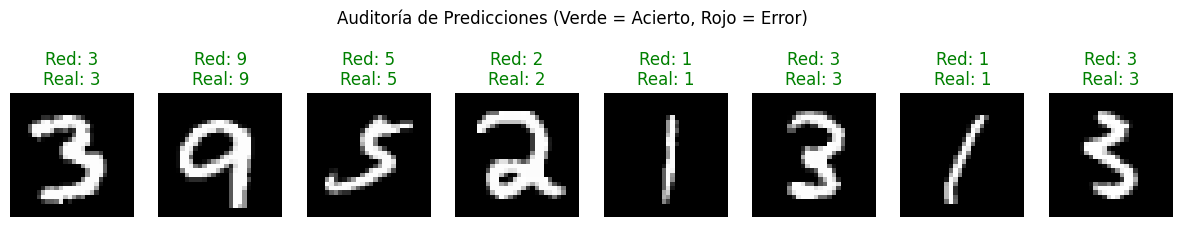

In [31]:
# visualizar y auditar varias imágenes para ver si falla o acierta
# Tomamos un lote de 8 imágenes (de la 500 a la 507)
imagenes_auditoria = X_test[500:508]
etiquetas_reales = y_test[500:508]

# La red hace las predicciones para todo el lote
predicciones_lote = red_250_2_5.predict(imagenes_auditoria, verbose=0)

# Creamos la cuadrícula de visualización
fig, ax = plt.subplots(1, 8, figsize=(15, 3))

for k in range(8):
    prediccion_red = predicciones_lote[k].argmax()
    real = etiquetas_reales[k]
    
    # Mostramos la imagen
    ax[k].imshow(imagenes_auditoria[k], cmap='gray')
    ax[k].axis('off')
    
    # Si acertó, título verde. Si falló, título rojo.
    color = 'green' if prediccion_red == real else 'red'
    ax[k].set_title(f"Red: {prediccion_red}\nReal: {real}", color=color)

plt.suptitle("Auditoría de Predicciones (Verde = Acierto, Rojo = Error)")
plt.show()

In [29]:
# 2. Para inspeccionar su estructura (Hacer un diagnóstico)
red_250_2_5.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_5 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 807,968 (3.08 MB)

 Trainable params: 269,322 (1.03 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 538,646 (2.05 MB)

In [ ]:
# 3. Para guardarla en el disco duro y no perder el entrenamiento
# red_250_2_5.save("red_250_2_5.h5") ; le decimos a la red que se guarde a si misma en un archivo llamado "red_250_2_5.h5" (el formato h5 es un formato común para guardar modelos de Keras)

In [32]:
# Ejercicio 2 - Compara 3 arquitecturas (32 / 128 / 128+128) y mira cual gana
red_32_1_5, acc_32_1_5 = construir_y_entrenar(neuronas=32, capas=1, epochs=5) 

Epoch 1/5
1688/1688 - 7s - 4ms/step - accuracy: 0.8943 - loss: 0.3765 - val_accuracy: 0.9478 - val_loss: 0.1959
Epoch 2/5
1688/1688 - 4s - 3ms/step - accuracy: 0.9410 - loss: 0.2047 - val_accuracy: 0.9597 - val_loss: 0.1487
Epoch 3/5
1688/1688 - 4s - 3ms/step - accuracy: 0.9537 - loss: 0.1593 - val_accuracy: 0.9635 - val_loss: 0.1329
Epoch 4/5
1688/1688 - 4s - 3ms/step - accuracy: 0.9604 - loss: 0.1350 - val_accuracy: 0.9672 - val_loss: 0.1151
Epoch 5/5
1688/1688 - 4s - 3ms/step - accuracy: 0.9654 - loss: 0.1167 - val_accuracy: 0.9675 - val_loss: 0.1207
>> Accuracy en test: 96.03 %


In [33]:
red_128_1_5, acc_128_1_5 = construir_y_entrenar(neuronas=128, capas=1, epochs=5) 

Epoch 1/5
1688/1688 - 8s - 5ms/step - accuracy: 0.9217 - loss: 0.2729 - val_accuracy: 0.9643 - val_loss: 0.1276
Epoch 2/5
1688/1688 - 6s - 4ms/step - accuracy: 0.9643 - loss: 0.1201 - val_accuracy: 0.9742 - val_loss: 0.0949
Epoch 3/5
1688/1688 - 6s - 3ms/step - accuracy: 0.9753 - loss: 0.0827 - val_accuracy: 0.9748 - val_loss: 0.0817
Epoch 4/5
1688/1688 - 6s - 3ms/step - accuracy: 0.9814 - loss: 0.0608 - val_accuracy: 0.9753 - val_loss: 0.0874
Epoch 5/5
1688/1688 - 6s - 3ms/step - accuracy: 0.9849 - loss: 0.0491 - val_accuracy: 0.9757 - val_loss: 0.0828
>> Accuracy en test: 97.89 %


In [34]:
red_128_2_5, acc_128_2_5 = construir_y_entrenar(neuronas=128, capas=2, epochs=5) 

Epoch 1/5
1688/1688 - 8s - 5ms/step - accuracy: 0.9288 - loss: 0.2454 - val_accuracy: 0.9675 - val_loss: 0.1135
Epoch 2/5
1688/1688 - 6s - 4ms/step - accuracy: 0.9682 - loss: 0.1034 - val_accuracy: 0.9745 - val_loss: 0.0870
Epoch 3/5
1688/1688 - 6s - 4ms/step - accuracy: 0.9776 - loss: 0.0716 - val_accuracy: 0.9780 - val_loss: 0.0753
Epoch 4/5
1688/1688 - 6s - 4ms/step - accuracy: 0.9822 - loss: 0.0542 - val_accuracy: 0.9802 - val_loss: 0.0714
Epoch 5/5
1688/1688 - 6s - 4ms/step - accuracy: 0.9861 - loss: 0.0409 - val_accuracy: 0.9755 - val_loss: 0.0842
>> Accuracy en test: 97.39 %


## Ejercicio 3 — ¿Qué confunde tu red? (con ropa)

Ahora con **Fashion-MNIST** (`keras.datasets.fashion_mnist`), donde las etiquetas 0–9 son tipos de ropa.

1. Entrena una red con el **mismo flujo** de siempre.
2. Predice **todo** el test y dibuja la **matriz de confusión** (`from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay`).
3. Mira la matriz y escribe en un comentario **qué dos prendas confunde más** la red.
4. Muestra **3 imágenes mal clasificadas** con un título tipo `dice X / es Y`.


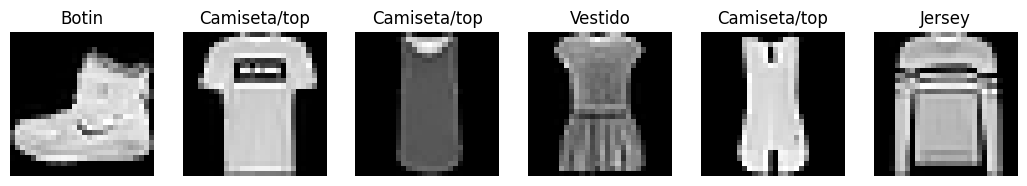

In [35]:
# Ejercicio 3 - Matriz de confusion y errores con Fashion-MNIST
# Esta lista traduce cada etiqueta (0-9) a su nombre, por si la necesitas:

# Aqui las etiquetas 0-9 son TIPOS DE ROPA, no numeros. Esta lista traduce cada numero a su nombre:
#   (la posicion 0 de la lista es el nombre de la etiqueta 0, la 1 el de la etiqueta 1, etc.)
clases = ['Camiseta/top', 'Pantalon', 'Jersey', 'Vestido', 'Abrigo',
          'Sandalia', 'Camisa', 'Zapatilla', 'Bolso', 'Botin']

# 🟦 DEMO - Cargamos Fashion-MNIST. Mismo formato que MNIST (28x28 gris), pero son PRENDAS de ropa.
(Xf_train, yf_train), (Xf_test, yf_test) = keras.datasets.fashion_mnist.load_data()

fig, ax = plt.subplots(1, 6, figsize=(13, 2.5))
for k in range(6):
    ax[k].imshow(Xf_train[k], cmap='gray') # muestra la imagen de la prenda de ropa
    ax[k].set_title(clases[yf_train[k]])   # clases[etiqueta] -> el NOMBRE en vez del numero
    ax[k].axis('off')  # quita los ejes para que se vea mas limpio
plt.show()

1) normaliza Xf_train y Xf_test (dividir entre 255)
2) construye una red Sequential (Input 28x28 -> Flatten -> Dense relu -> Dense 10 softmax)
3) compila (optimizer adam, loss sparse_categorical_crossentropy, metrics accuracy)
4) entrena con fit
5) evalua con evaluate

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.8208 - loss: 0.5103 - val_accuracy: 0.8525 - val_loss: 0.4090
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8621 - loss: 0.3845 - val_accuracy: 0.8648 - val_loss: 0.3681
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8754 - loss: 0.3413 - val_accuracy: 0.8745 - val_loss: 0.3460
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8841 - loss: 0.3170 - val_accuracy: 0.8707 - val_loss: 0.3424
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8913 - loss: 0.2938 - val_accuracy: 0.8777 - val_loss: 0.3335
Accuracy en test (ropa): 87.5 %


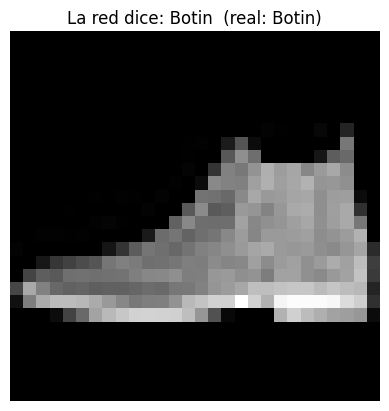

In [36]:
# -- SOLUCION  --
Xf_train = Xf_train / 255.0                   # 1) normalizar (mismo motivo que en MNIST: numeros 0-1)
Xf_test  = Xf_test  / 255.0

red_ropa = keras.Sequential([                  # 2) construir (MISMA estructura que el Bloque 1)
    keras.layers.Input(shape=(28, 28)),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10,  activation='softmax'),
])
red_ropa.compile(optimizer='adam',               # 3) compilar (identico a MNIST)
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])
red_ropa.fit(Xf_train, yf_train, epochs=5, validation_split=0.1)   # 4) entrenar
acc = red_ropa.evaluate(Xf_test, yf_test, verbose=0)[1]           # 5) evaluar (accuracy en test)
print('Accuracy en test (ropa):', round(acc * 100, 1), '%')

# Predecimos una prenda y la ensenamos con su NOMBRE (traduciendo la etiqueta con la lista 'clases'):
i = 0
pred = int(red_ropa.predict(Xf_test[i:i+1], verbose=0).argmax())   # digito/clase predicha
plt.imshow(Xf_test[i], cmap='gray'); plt.axis('off')
plt.title('La red dice: ' + clases[pred] + '  (real: ' + clases[yf_test[i]] + ')')
plt.show()

Una vez, logrado obtener la red está entrenada, vamos a resolver el resto del ejercicio paso a paso: hacer las predicciones globales, construir la matriz de confusión para ver dónde se equivoca y cazar esas 3 imágenes mal clasificadas para auditarlas visualmente.

Paso 1: Predecir TODO el test
Para saber qué prendas confunde la red, primero necesitamos que haga el "examen completo", es decir, que prediga todas las imágenes del conjunto de test (Xf_test).

¿Por qué hacemos esto? preds_todas es una matriz gigante llenas de probabilidades. Al usar .argmax(axis=1), le decimos a Python: "Recorre cada fila (cada imagen) y dime cuál fue el dígito con mayor probabilidad". Ahora preds_clases contiene las 10,000 respuestas finales de la red.

In [38]:
# 1. Pedimos las probabilidades de TODO el dataset de test (las 10,000 imágenes)
preds_todas = red_ropa.predict(Xf_test, verbose=0)

# 2. Usamos argmax en el eje 1 (axis=1) para quedarnos con el número de clase ganador para cada imagen
preds_clases = preds_todas.argmax(axis=1)

Paso 2: Dibujar la Matriz de Confusión
Una matriz de confusión es un mapa bidimensional. En un eje tenemos lo que la prenda es en realidad (etiqueta real) y en el otro lo que la red dice que es (predicción). Los aciertos se concentran en la diagonal principal; cualquier número fuera de esa diagonal es un error.

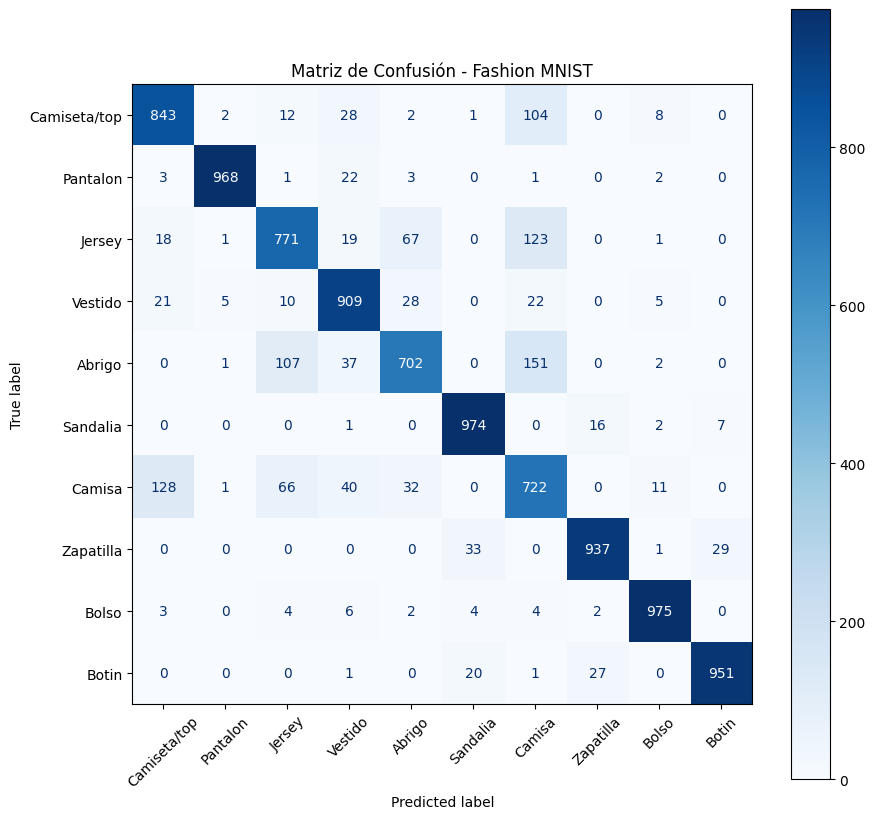

In [39]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Calculamos la matriz matemática comparando lo real (yf_test) con lo predicho (preds_clases)
cm = confusion_matrix(yf_test, preds_clases)

# 2. Configuramos la visualización gráfica usando los nombres de la ropa ('clases')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clases)

# 3. Lo dibujamos en pantalla con un tamaño cómodo y girando los nombres para que se lean bien
fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, cmap='Blues', values_format='d') # 'd' muestra números enteros
plt.xticks(rotation=45)
plt.title('Matriz de Confusión - Fashion MNIST')
plt.show()

¿Cómo interpretar la matriz para responder al punto 3?
Cuando ejecutes este código, verás un mapa de calor azul. Para saber qué dos prendas confunde más la red, debes buscar el número más alto que esté FUERA de la diagonal principal.

- Típicamente, en Fashion-MNIST la red suele confundir mucho las Camisas (Shirt) con las Camisetas (T-shirt/top) o los Abrigos (Coat) con los Pulóveres/Jerseys (Pullover). Es lógico, ¡porque sus siluetas de píxeles grises son sumamente parecidas!

Comentario: La red confunde más la prenda X con la prenda Y (por ejemplo, Shirt con T-shirt).

Paso 3: Encontrar y mostrar 3 imágenes mal clasificadas
El último punto te pide buscar ejemplos donde la red haya fallado estrepitosamente para ver qué "vio" el algoritmo.

Para lograrlo, primero identificamos en qué posiciones los vectores preds_clases y yf_test no coinciden.

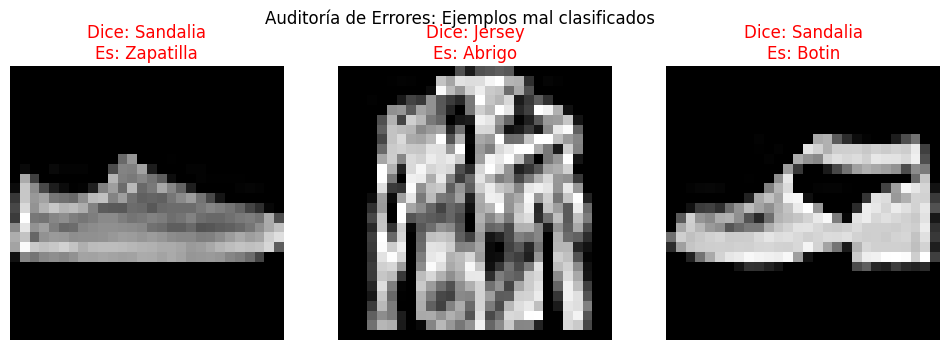

In [40]:
# 1. Buscamos los índices (las posiciones) donde la predicción fue diferente al valor real
indices_errores = []
for i in range(len(yf_test)):
    if preds_clases[i] != yf_test[i]:
        indices_errores.append(i)

# 2. Creamos una ventana gráfica para mostrar 3 imágenes
fig, ax = plt.subplots(1, 3, figsize=(12, 4))

# 3. Tomamos los 3 primeros errores que encontramos y los dibujamos
for k in range(3):
    idx = indices_errores[k] # Conseguimos el índice real del fallo
    
    # Extraemos el nombre de lo que la red dijo y lo que era en realidad
    nombre_predicho = clases[preds_clases[idx]]
    nombre_real = clases[yf_test[idx]]
    
    # Pintamos la imagen en su respectivo subgráfico
    ax[k].imshow(Xf_test[idx], cmap='gray')
    ax[k].axis('off')
    
    # Le ponemos el título con el formato exigido: "dice X / es Y"
    ax[k].set_title(f"Dice: {nombre_predicho}\nEs: {nombre_real}", color='red')

plt.suptitle("Auditoría de Errores: Ejemplos mal clasificados")
plt.show()

Ejemplo 1: Automatización en un Aparcamiento Inteligente (Parking)
Imagina un aparcamiento que quiere automatizar el cobro sin que los usuarios tengan que introducir manualmente el número de plaza o el ticket en el cajero.

[ Cámara en la Plaza ] 📷 
       │ (Toma foto del número pintado en el suelo)
       ▼
[ Servidor Local / API ] 🖥️ 
       │ (Corta la foto en dígitos individuales y los normaliza a 28x28)
       ▼
[ Tu Modelo Red Neuronal ] 🧠 
       │ (Predice: "9", "4", "2")
       ▼
[ Base de Datos de Gestión ] 📊 ➔ (Registra: Plaza 942 ocupada a las 10:00)

¿Cómo se implementa en la vida real?
1- Captura: Una cámara enfoca el número de la plaza pintado en el suelo o en la pared.
2- Preprocesamiento (Crítico): El software de la cámara detecta dónde está el número, recorta cada dígito por separado, los convierte a escala de grises y los redimensiona exactamente a un formato de 28x28 píxeles, dividiendo los valores entre 255.0 (tal como hiciste en el ejercicio).
3- Inferencia: El script de Python de la empresa carga tu modelo guardado (red_128_1_5.keras) y procesa el recorte:
numero_plaza = red_128_1_5.predict(digitos_recortados).argmax(axis=1)
4- Acción: El sistema registra en la base de datos que la plaza está ocupada y empieza a contar el tiempo para la facturación.

Ejemplo 2: Triaje y Clasificación Automática en Almacenes de Moda (E-commerce)
Hablemos ahora de tu red de Fashion-MNIST. Imagina una empresa de logística de ropa de segunda mano o devoluciones automáticas (como Amazon o Zalando).

El problema: Llegan miles de prendas devueltas en cajas y los operarios pierden mucho tiempo clasificando si lo que llegó es un pantalón, un vestido o una bota para enviarlo al pasillo correcto del almacén.

La solución en producción: La prenda pasa por una cinta transportadora bajo una cámara cenital. El sistema toma una foto rápida, la silueta de la prenda se aísla, se reduce a una matriz gris y tu modelo red_ropa dictamina: "Esto es un 'Ankle Boot' (Bota) con 98% de confianza".

El proceso productivo: Un brazo robótico o una compuerta neumática en la cinta recibe la orden del código y desvía la prenda automáticamente hacia el contenedor de calzado.

Ejemplo 3: Contabilidad y Auditoría: Lectura de Cheques o Facturas
En el sector financiero o de seguros, la digitalización de documentos en papel es un dolor de cabeza constante.

Caso de uso: Una empresa recibe cientos de facturas escaneadas o cheques firmados a mano. Necesitan extraer el importe total sin que una persona tenga que leerlos uno a uno.

Cómo funciona: Un software OCR (Reconocimiento Óptico de Caracteres) localiza el recuadro del "Total a pagar". Al ser números manuscritos, se le envían las imágenes recortadas de los dígitos a tu modelo red_128_1_5.

Control de Riesgos (Auditoría): Aquí usamos las probabilidades de softmax. Si la red lee un número pero dice: "Creo que es un 8, pero solo tengo un 52% de confianza (estoy dudosa)", el sistema de producción frena el proceso y envía esa factura a una bandeja de "Revisión Humana". Si la confianza es mayor al 95%, se aprueba y contabiliza automáticamente.

¿Cómo se conecta tu archivo .keras al mundo real?
Para que cualquiera de los ejemplos anteriores funcione, el modelo no se queda aislado. Se suele empaquetar en una API (un servicio web) usando herramientas de Python como FastAPI o Flask.

El esquema de producción funciona así:

La aplicación cliente (la cámara del parking o la app del móvil) envía la foto a través de internet a un servidor central.

El servidor recibe la foto, corre el modelo con modelo.predict() en milisegundos.

El servidor responde con un simple texto en formato JSON: {"prediccion": 3, "confianza": 97.8}.

El hardware del cliente reacciona (se abre la barrera del parking o se mueve el robot).

# Parte B — YOLO

> En esta parte **no entrenamos nada**: usamos un modelo de YOLO que ya viene entrenado. Es lo que vimos en el remate de clase.

## Ejercicio 4 — Detecta objetos en una imagen

1. Carga el modelo: `modelo = YOLO('yolo11n.pt')` (se descarga solo la primera vez).
2. Pásale una imagen: la de ejemplo `foto.jpg` (te la prepara la celda de abajo) **o** una tuya guardada como `mi_foto.jpg`.
3. Muestra la imagen con las cajas dibujadas usando `resultado[0].plot()`. Recuerda pasar de BGR a RGB con `[:, :, ::-1]`.
4. Imprime la lista de objetos detectados.


In [ ]:
# Ejercicio 4 - Detecta objetos en una imagen
from ultralytics import YOLO
import urllib.request, os

# Preparamos una imagen de ejemplo (si no tienes una propia):
if not os.path.exists('foto.jpg'):
    urllib.request.urlretrieve('https://ultralytics.com/images/bus.jpg', 'foto.jpg')


# TODO

## Ejercicio 5 — Cuenta cuántas personas hay

Usando YOLO sobre una imagen con gente (la de ejemplo `foto.jpg` sirve), **cuenta cuántas personas** detecta e imprime un mensaje tipo:
> `Hay 4 personas en la imagen`

💡 *Pista: recorre `resultado[0].boxes.cls`. Cada valor es el número de una clase; su nombre lo da `modelo.names[int(c)]`. Cuenta cuántos son `'person'`. (También puedes hacerlo con una lista por comprensión si te animas.)*

In [ ]:
# Ejercicio 5 - Cuenta las personas detectadas

# TODO

## Ejercicio 6 — El umbral de confianza (`conf`)

YOLO solo muestra las detecciones cuya **confianza** supera un umbral llamado `conf` (por defecto, 0.25). Vamos a jugar con él:

1. Corre YOLO sobre la misma imagen con `modelo('foto.jpg', conf=0.25)` y mira **cuántos objetos** detecta.
2. Corre otra vez con `conf=0.7` y cuenta de nuevo.
3. Escribe en un comentario: ¿con cuál detecta **más** objetos? ¿Por qué crees que pasa?

💡 *Pista: `len(resultado[0].boxes)` te dice cuántos objetos ha detectado. Subir el umbral = la red se vuelve más exigente y solo enseña lo que ve muy claro.*
⭐ *Bonus: prueba un modelo más grande con `YOLO('yolo11s.pt')` ('s' = small) y mira si detecta más cosas que el `'n'` (nano).*

In [ ]:
# Ejercicio 6 - Compara conf=0.25 vs conf=0.7

# TODO